In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [4]:
df=pd.read_csv('C:\\Users\\joel4\\Documents\\ecommerce-customer-analytics\\data\\online_retail_cleaned.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [5]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

In [6]:
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')

In [7]:
invoice_year = df['InvoiceDate'].dt.year
invoice_month = df['InvoiceDate'].dt.month

cohort_year = df['CohortMonth'].dt.year
choort_month = df['CohortMonth'].dt.month

df['CohortIndex'] = (
    (invoice_year - cohort_year) * 12 + (invoice_month - choort_month) + 1
)

In [8]:
cohort_data = df.groupby(
    ['CohortMonth', 'CohortIndex']
)['CustomerID'].nunique().reset_index()

In [9]:
cohort_table = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='CustomerID'
)

In [10]:
cohort_size = cohort_table.iloc[:, 0]
retention = cohort_table.divide(cohort_size, axis=0)

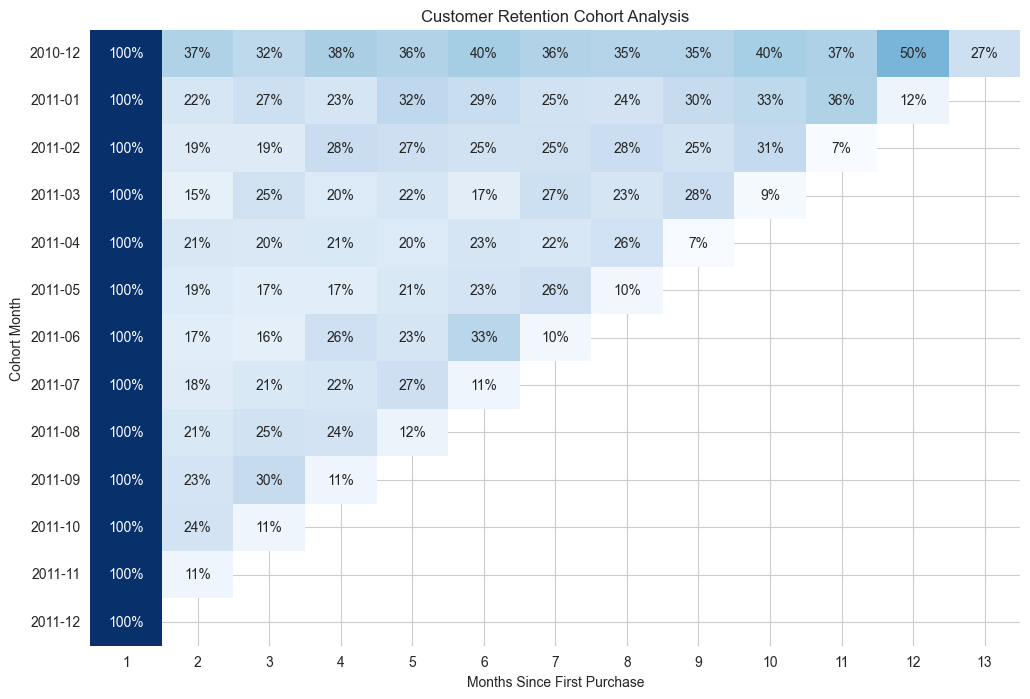

In [11]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    retention,
    annot=True,
    fmt='.0%',
    cmap='Blues',
    cbar=False
)

plt.title("Customer Retention Cohort Analysis")
plt.ylabel("Cohort Month")
plt.xlabel("Months Since First Purchase")
plt.show()